# Notebook 2: Exploratory Data Analysis

This notebook explores the daily-aggregated datasets produced in Notebook 1. The goal is to understand the structure of the data, assess the relationships between sentiment features and price movement, and identify which models and features are most likely to be useful for classification.

**Sections:**
1. Price and volume overview
2. Direction class balance (post-level vs. daily-level)
3. Sentiment distributions by direction
4. Model agreement (correlation heatmap)
5. GoEmotions emotional profile
6. Feature correlation with price movement
7. Weighted vs. unweighted sentiment comparison

## Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
SAVE_DIR = "/content/drive/MyDrive/UC Berkeley/Capstone Project/"

df = pd.read_parquet(SAVE_DIR + "df_with_all_sentiments.parquet")
df_daily = pd.read_parquet(SAVE_DIR + "dataset2_daily_unweighted.parquet")
df_daily_weighted = pd.read_parquet(SAVE_DIR + "dataset3_daily_weighted.parquet")

# Ensure Date columns are datetime
df_daily["Date"] = pd.to_datetime(df_daily["Date"])
df_daily_weighted["Date"] = pd.to_datetime(df_daily_weighted["Date"])

print(f"Post-level:       {df.shape}")
print(f"Daily unweighted: {df_daily.shape}")
print(f"Daily weighted:   {df_daily_weighted.shape}")

Post-level:       (35735, 54)
Daily unweighted: (44, 102)
Daily weighted:   (44, 102)


## Section 1: Price and Volume Overview

This dual-axis time series chart shows GME's daily net price movement (green/red bars) alongside the daily volume of r/wallstreetbets posts (blue line) from January 28 to March 31, 2021. The histogram below shows the distribution of daily post counts across all 44 trading days. Together, these charts establish the timeline of events and reveal the relationship between market activity and community engagement.

**Key findings:** The most notable feature is the spike in Reddit activity on January 28–29, coinciding with the peak of the short squeeze. After this, activity returned to a low baseline. Post volume appears to trail price movement rather than lead it, suggesting the community was largely reactive rather than predictive during this period. The post volume distribution is heavily right-skewed: 37 of 44 days had fewer than 1,000 posts, while January 29 alone accounts for nearly 16,000 posts (approximately 44% of all data). This skew means that at the post level, nearly half the training data comes from a single day's characteristics, which could bias classifiers. This motivates aggregating the data to the daily level.

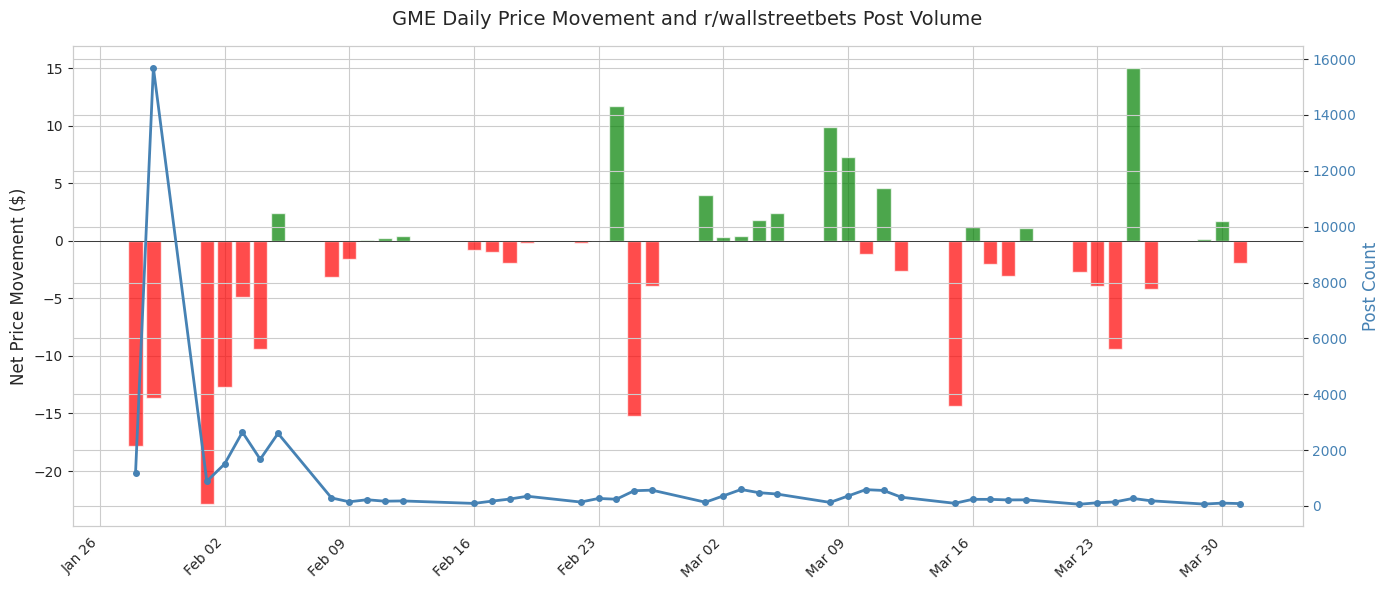

In [4]:
fig, ax1 = plt.subplots(figsize=(14, 6))

colors = ["green" if x > 0 else "red" for x in df_daily["Net_Movement"]]
ax1.bar(df_daily["Date"], df_daily["Net_Movement"], color=colors, alpha=0.7, width=0.8)
ax1.set_ylabel("Net Price Movement ($)", fontsize=12)
ax1.set_xlabel("")
ax1.axhline(y=0, color="black", linewidth=0.5)

ax2 = ax1.twinx()
ax2.plot(df_daily["Date"], df_daily["post_count"], color="steelblue", linewidth=2, marker="o", markersize=4)
ax2.set_ylabel("Post Count", fontsize=12, color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")

ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.title("GME Daily Price Movement and r/wallstreetbets Post Volume", fontsize=14, pad=15)
fig.tight_layout()
plt.show()

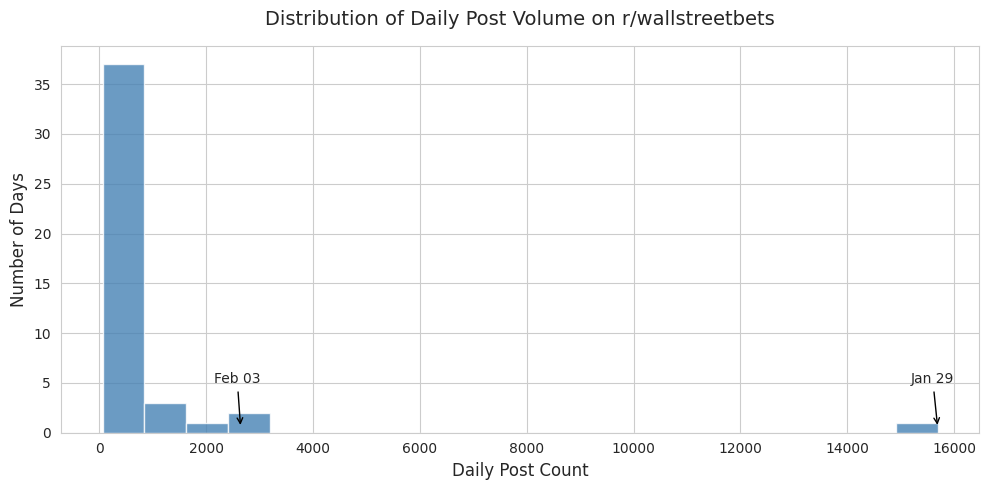

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df_daily["post_count"], bins=20, color="steelblue", edgecolor="white", alpha=0.8)
ax.set_xlabel("Daily Post Count", fontsize=12)
ax.set_ylabel("Number of Days", fontsize=12)
ax.set_title("Distribution of Daily Post Volume on r/wallstreetbets", fontsize=14, pad=15)

# Annotate outlier days
top_days = df_daily.nlargest(2, "post_count")
for _, row in top_days.iterrows():
    ax.annotate(
        row["Date"].strftime("%b %d"),
        xy=(row["post_count"], 0.5),
        xytext=(row["post_count"] - 500, 5),
        fontsize=10,
        arrowprops=dict(arrowstyle="->", color="black"),
    )

fig.tight_layout()
plt.show()

## Section 2: Direction Class Balance

This side-by-side chart compares the class distribution of price direction at the post level (35,735 posts) versus the daily level (44 days). This comparison illustrates why the unit of analysis fundamentally changes the apparent class balance of the prediction task.

**Key findings:** At the post level, the data appears severely imbalanced (79.5% down, 20.5% up). At the daily level, the split is much more balanced (59.1% down, 40.9% up). The apparent 80/20 imbalance is an artifact of high-volume down days, particularly January 28–29, contributing disproportionately more posts. The paper's post-level classifiers were likely biased toward predicting "down" because that class dominated the training data. At the daily level, the 59/41 split is manageable without aggressive class weighting. To verify this, classifiers are trained on both levels and compared in Notebook 3.

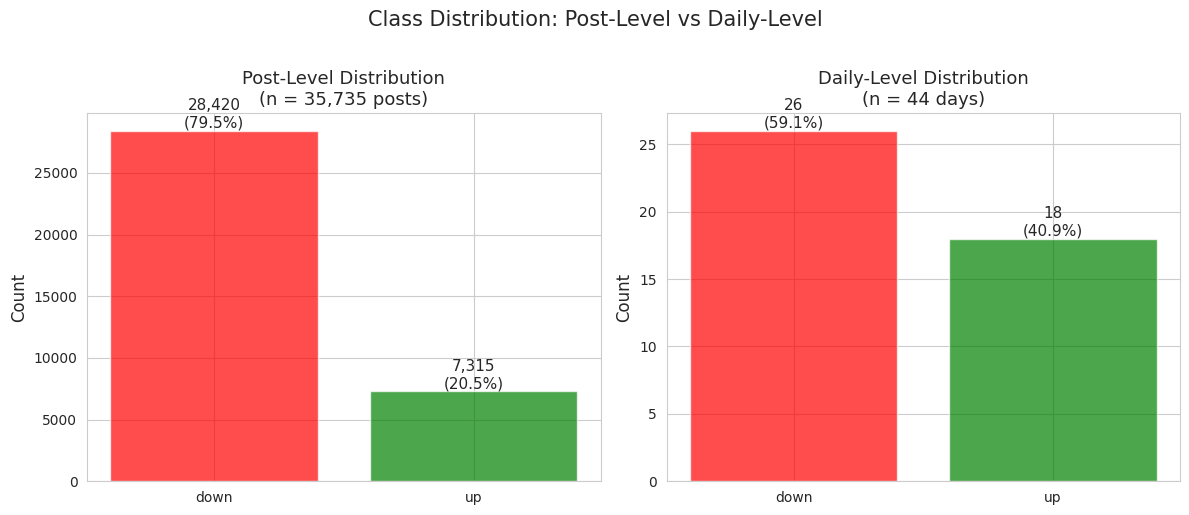

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Post-level distribution
post_counts = df["Direction"].value_counts()
post_pcts = df["Direction"].value_counts(normalize=True) * 100
bars1 = ax1.bar(
    ["down", "up"],
    [post_counts["down"], post_counts["up"]],
    color=["red", "green"], alpha=0.7, edgecolor="white"
)
ax1.set_title("Post-Level Distribution\n(n = 35,735 posts)", fontsize=13)
ax1.set_ylabel("Count", fontsize=12)
for bar, count, pct in zip(bars1, [post_counts["down"], post_counts["up"]], [post_pcts["down"], post_pcts["up"]]):
    ax1.annotate(
        f"{count:,}\n({pct:.1f}%)",
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center", va="bottom", fontsize=11
    )

# Daily-level distribution
daily_counts = df_daily["Direction"].value_counts()
daily_pcts = df_daily["Direction"].value_counts(normalize=True) * 100
bars2 = ax2.bar(
    ["down", "up"],
    [daily_counts["down"], daily_counts["up"]],
    color=["red", "green"], alpha=0.7, edgecolor="white"
)
ax2.set_title("Daily-Level Distribution\n(n = 44 days)", fontsize=13)
ax2.set_ylabel("Count", fontsize=12)
for bar, count, pct in zip(bars2, [daily_counts["down"], daily_counts["up"]], [daily_pcts["down"], daily_pcts["up"]]):
    ax2.annotate(
        f"{count}\n({pct:.1f}%)",
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center", va="bottom", fontsize=11
    )

plt.suptitle("Class Distribution: Post-Level vs Daily-Level", fontsize=15, y=1.02)
fig.tight_layout()
plt.show()

## Section 3: Sentiment Distributions by Direction

This 3x4 grid of box plots compares the distributions of positive, neutral, and negative sentiment scores on up versus down days across four sentiment models. Individual data points are overlaid as strip plots since the sample size of 44 days is small enough to visualize every observation. This directly addresses whether any sentiment model produces scores that meaningfully differentiate between up and down trading days.

**Key findings:** The distributions overlap substantially across all four models. FinBERT's neutral score shows the most visible difference, with down days registering higher neutral sentiment than up days. Counterintuitively, negative scores across FinBERT, Twitter-RoBERTa, and Topic-Sentiment are slightly higher on up days than down days. This likely reflects the linguistic culture of r/wallstreetbets on bullish days: posts aggressively attacking short sellers register as negative even when the underlying sentiment toward GME is positive. This pattern reinforces the concern that sentiment tracks price reactively rather than predictively.

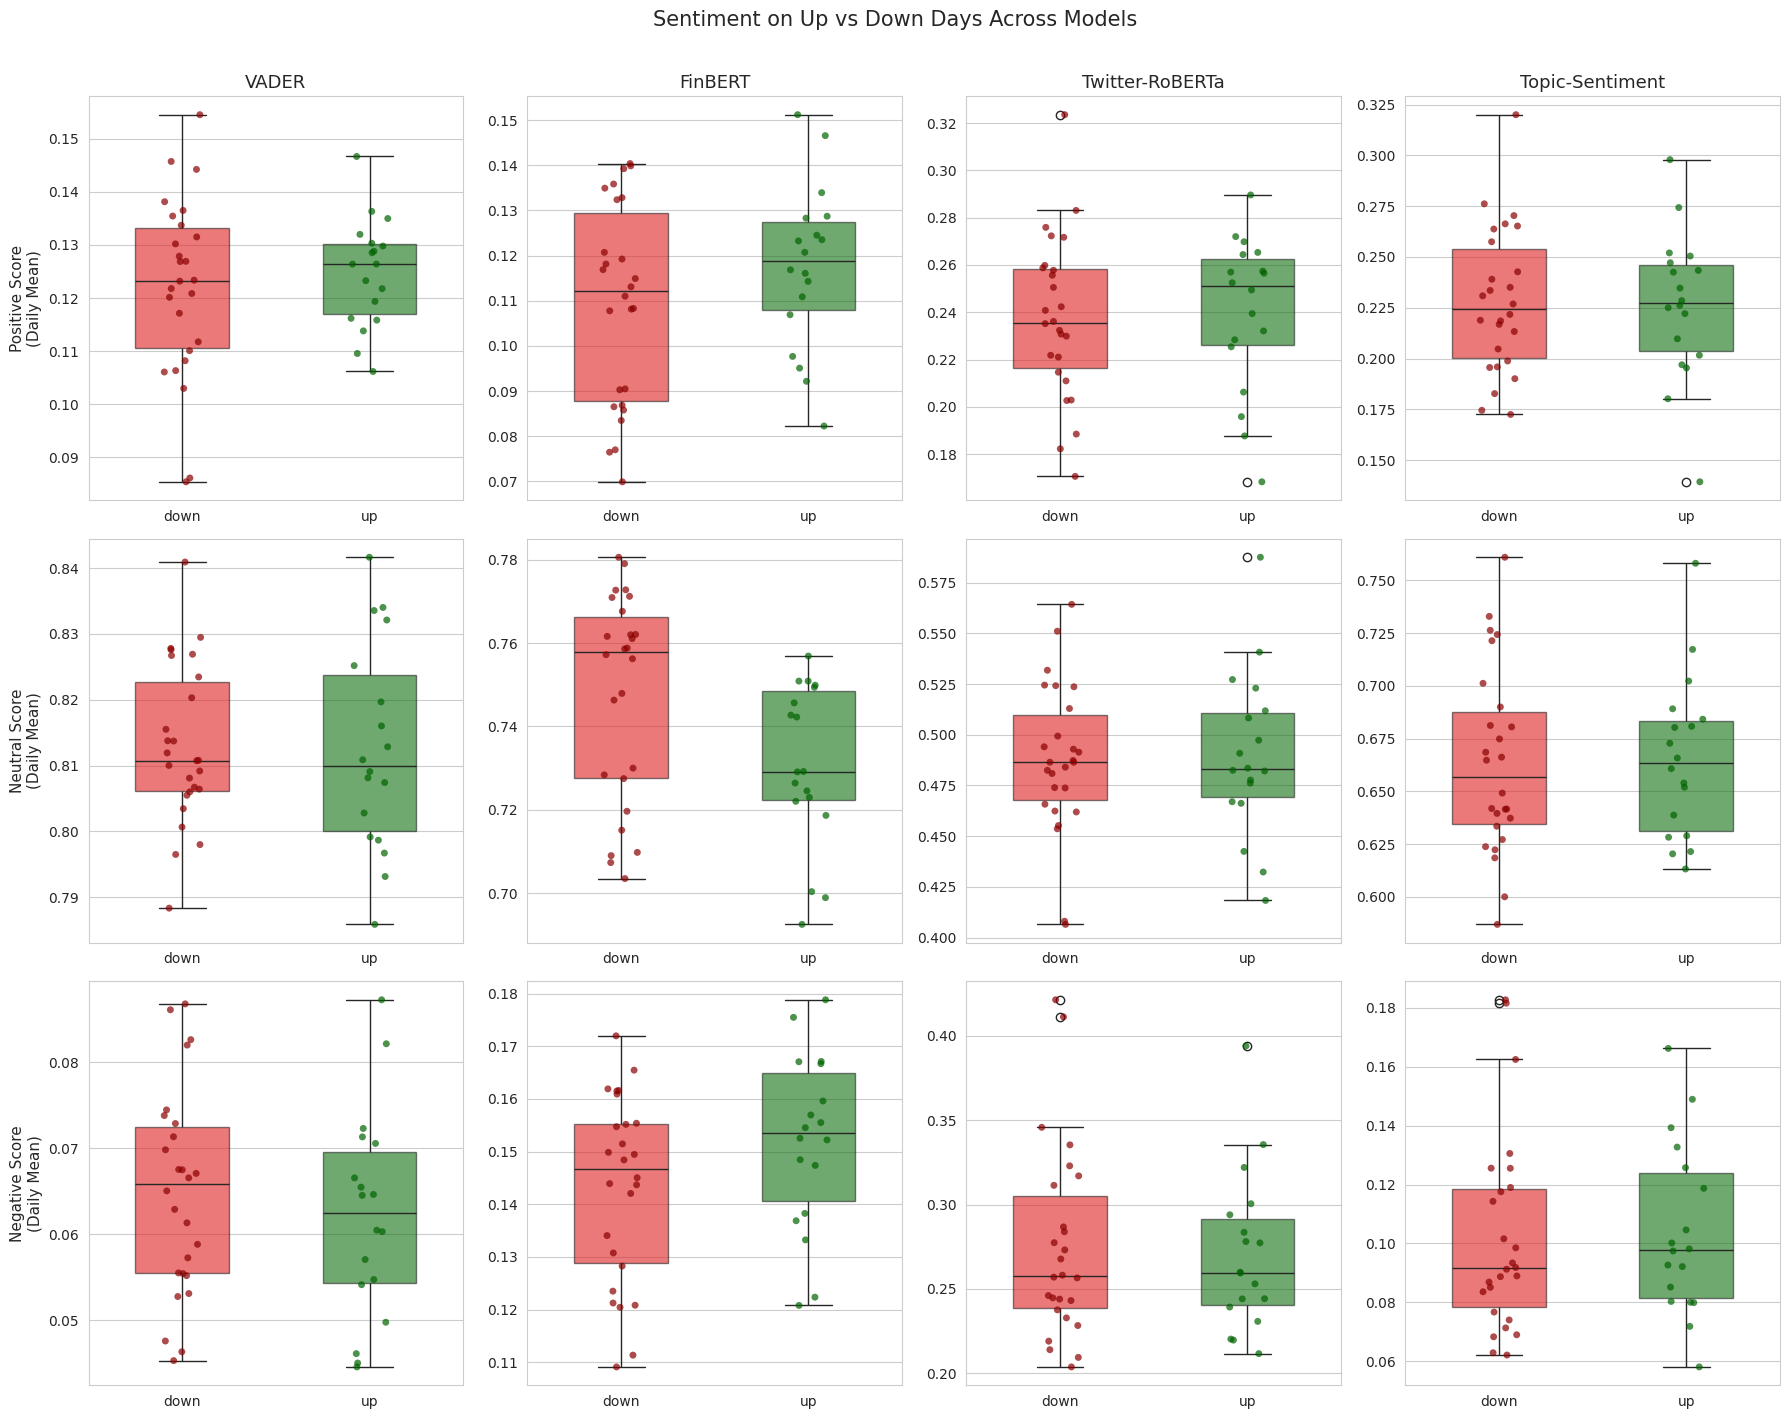

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(18, 14))

models = [
    ("VADER", "vader_pos_mean", "vader_neu_mean", "vader_neg_mean"),
    ("FinBERT", "finbert_pos_mean", "finbert_neu_mean", "finbert_neg_mean"),
    ("Twitter-RoBERTa", "roberta_pos_mean", "roberta_neu_mean", "roberta_neg_mean"),
    ("Topic-Sentiment", "topic_pos_mean", "topic_neu_mean", "topic_neg_mean"),
]

row_labels = ["Positive", "Neutral", "Negative"]

for col_idx, (name, pos_col, neu_col, neg_col) in enumerate(models):
    for row_idx, col in enumerate([pos_col, neu_col, neg_col]):
        ax = axes[row_idx, col_idx]
        sns.boxplot(
            data=df_daily, x="Direction", y=col, order=["down", "up"],
            hue="Direction", hue_order=["down", "up"],
            palette={"down": "red", "up": "green"}, width=0.5,
            boxprops=dict(alpha=0.6), legend=False, ax=ax
        )
        sns.stripplot(
            data=df_daily, x="Direction", y=col, order=["down", "up"],
            hue="Direction", hue_order=["down", "up"],
            palette={"down": "darkred", "up": "darkgreen"}, size=5,
            alpha=0.7, jitter=True, legend=False, ax=ax
        )
        ax.set_xlabel("")
        if row_idx == 0:
            ax.set_title(name, fontsize=13)
        if col_idx == 0:
            ax.set_ylabel(f"{row_labels[row_idx]} Score\n(Daily Mean)", fontsize=11)
        else:
            ax.set_ylabel("")

plt.suptitle("Sentiment on Up vs Down Days Across Models", fontsize=15, y=1.01)
fig.tight_layout()
plt.show()

## Section 4: Model Agreement

This correlation heatmap shows pairwise Pearson correlations between all positive, neutral, and negative daily mean scores across the four sentiment models. Understanding model agreement is essential for determining whether combining multiple models adds unique information or merely introduces redundancy.

**Key findings:** Twitter-RoBERTa and Topic-Sentiment are highly correlated across all score types (negative: r=0.89, neutral: r=0.87, positive: r=0.75), which is expected given their shared RoBERTa architecture and social media training domain. Using both adds redundancy rather than unique signal. VADER is the most distinct model, with near-zero correlations against most transformer features, confirming that its rule-based approach captures fundamentally different information. FinBERT shows moderate correlations with both VADER and the social media models, reflecting its unique financial domain training. The most informative model combination would be VADER, FinBERT, and one of the social media models.

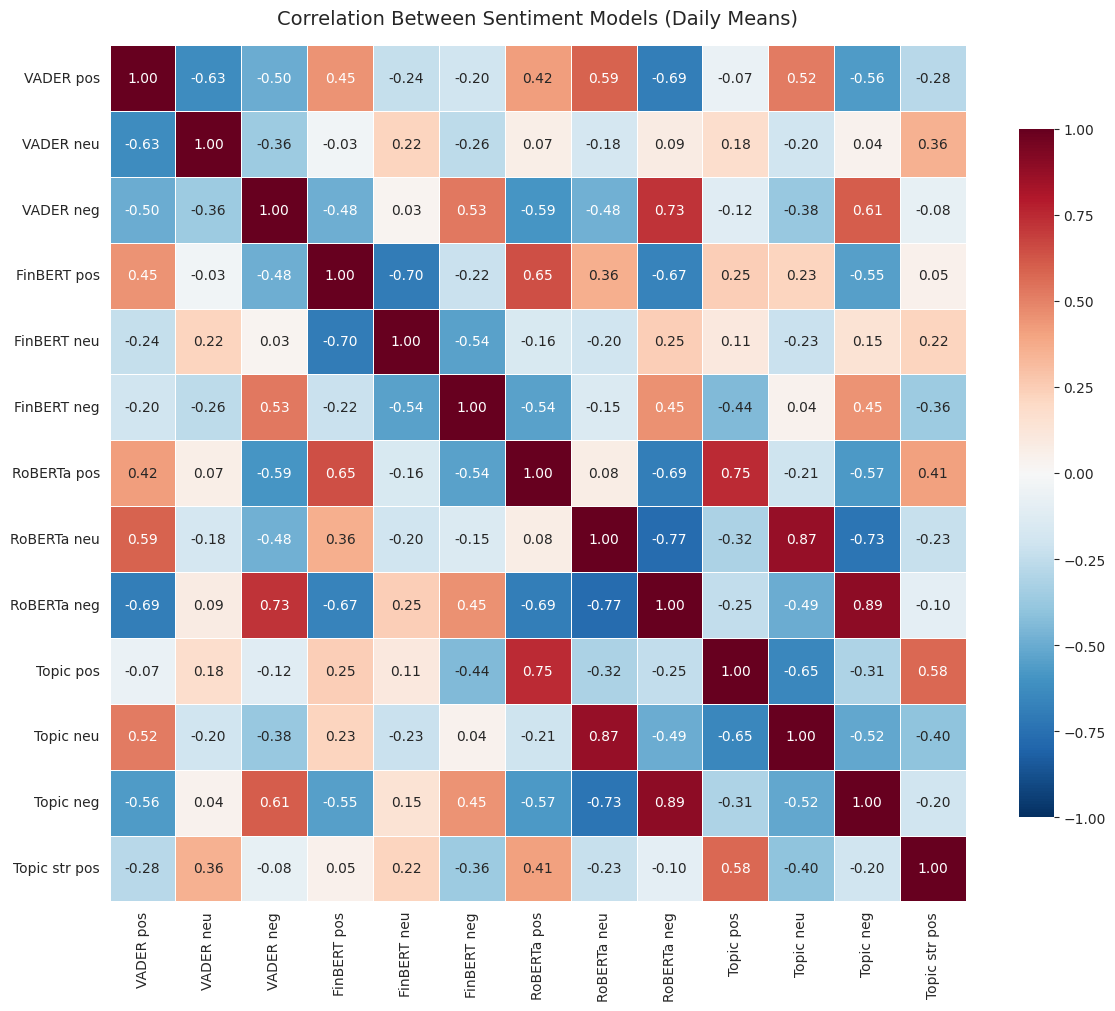

In [8]:
corr_features = {
    "vader_pos_mean": "VADER pos", "vader_neu_mean": "VADER neu", "vader_neg_mean": "VADER neg",
    "finbert_pos_mean": "FinBERT pos", "finbert_neu_mean": "FinBERT neu", "finbert_neg_mean": "FinBERT neg",
    "roberta_pos_mean": "RoBERTa pos", "roberta_neu_mean": "RoBERTa neu", "roberta_neg_mean": "RoBERTa neg",
    "topic_pos_mean": "Topic pos", "topic_neu_mean": "Topic neu", "topic_neg_mean": "Topic neg",
    "topic_strong_pos_mean": "Topic str pos",
}

corr_df = df_daily[list(corr_features.keys())].rename(columns=corr_features)
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.5,
    cbar_kws={"shrink": 0.8}, ax=ax
)
ax.set_title("Correlation Between Sentiment Models (Daily Means)", fontsize=14, pad=15)
fig.tight_layout()
plt.show()

## Section 5: GoEmotions Emotional Profile

The first chart ranks the top 10 emotions detected by GoEmotions across all posts. The second chart is a heatmap comparing the average score for all 28 emotions on down versus up days, with a difference column sorted by absolute magnitude. These charts characterize the emotional profile of r/wallstreetbets during the GME saga and identify which emotions differentiate between up and down days.

**Key findings:** Neutral dominates at approximately 0.65, mirroring the pattern observed with VADER and FinBERT. After neutral, approval and annoyance are most prevalent — fitting a community that simultaneously cheerleads its members and rages at institutional players. The up-vs-down differences are small in absolute magnitude (the largest is approval at 0.0054), but the qualitative patterns are interesting. Up days show higher approval, realization, confusion, and surprise — cognitive processing emotions consistent with reacting to unexpected gains. Down days show higher love, gratitude, anger, and excitement, reflecting the "diamond hands" solidarity culture where members express loyalty and gratitude for holding through losses. GoEmotions captures culturally specific emotional dynamics that positive/negative/neutral models miss.

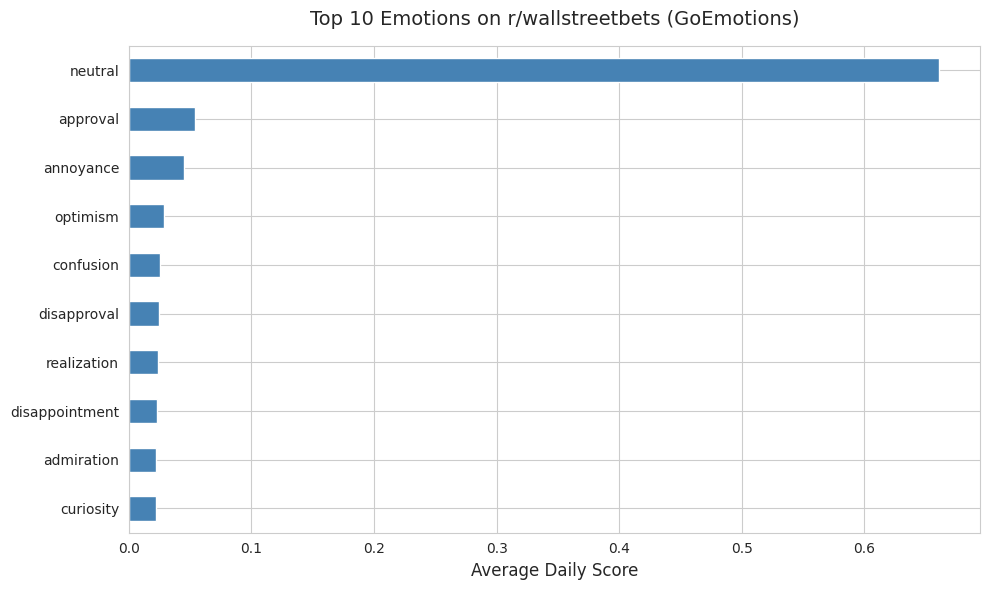

In [9]:
emotion_cols = [c for c in df_daily.columns if c.startswith("emo_") and c.endswith("_mean")]
emotion_labels = [c.replace("emo_", "").replace("_mean", "") for c in emotion_cols]

# Top 10 emotions by average score
avg_emotions = df_daily[emotion_cols].mean().sort_values(ascending=False)
avg_emotions.index = [c.replace("emo_", "").replace("_mean", "") for c in avg_emotions.index]
top_10 = avg_emotions.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
top_10.sort_values().plot.barh(ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Average Daily Score", fontsize=12)
ax.set_ylabel("")
ax.set_title("Top 10 Emotions on r/wallstreetbets (GoEmotions)", fontsize=14, pad=15)
fig.tight_layout()
plt.show()

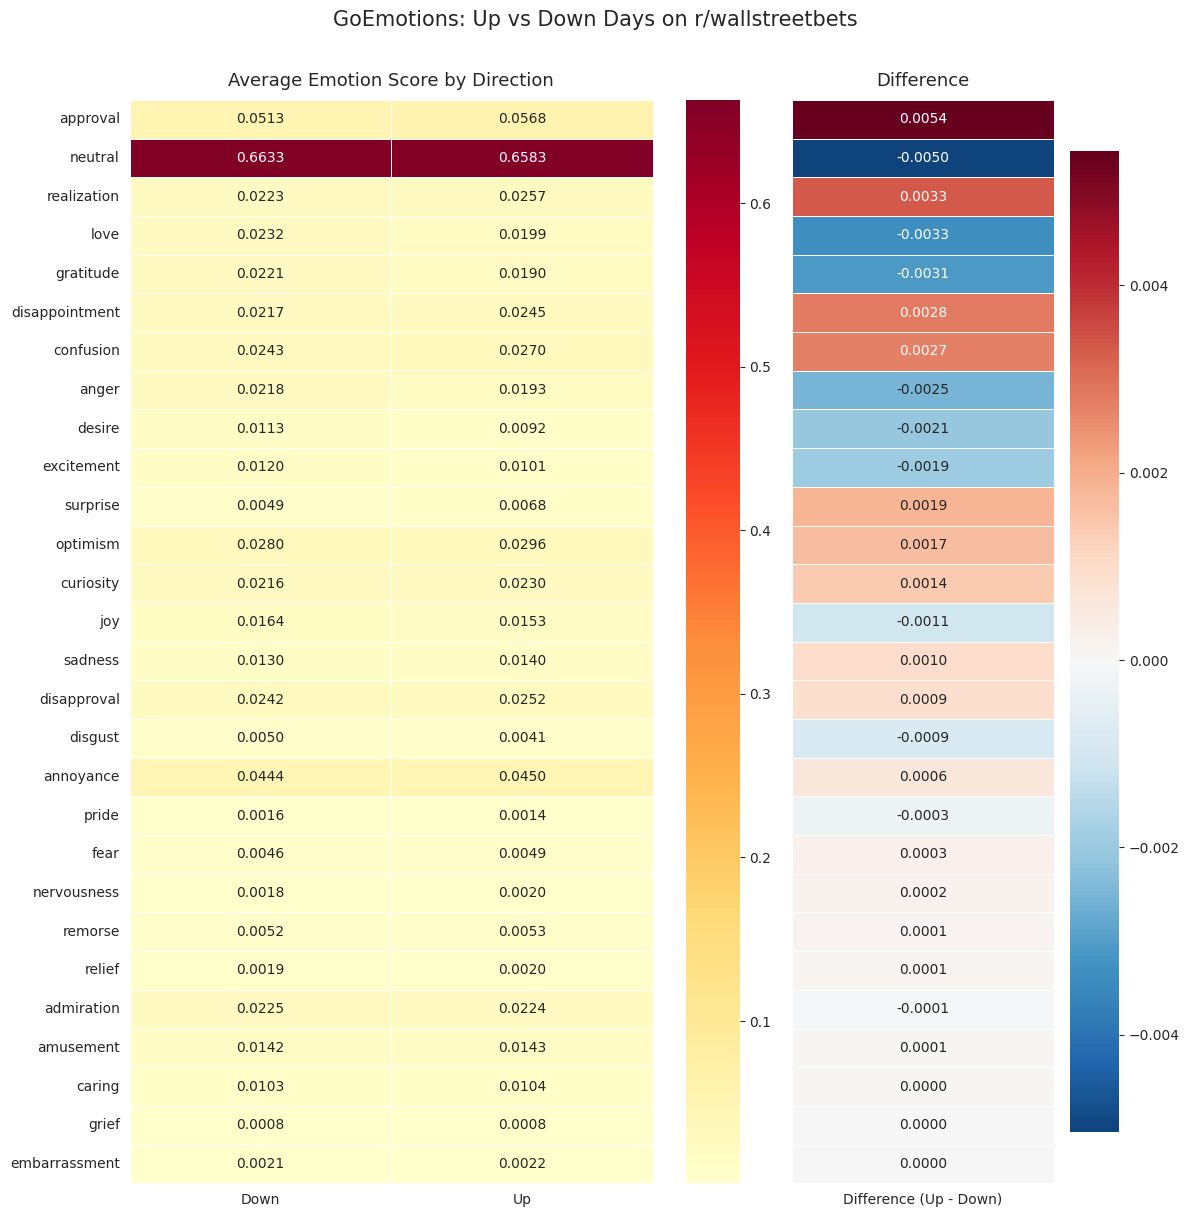

In [10]:
# Emotion heatmap: Up vs Down days
down_means = df_daily[df_daily["Direction"] == "down"][emotion_cols].mean()
up_means = df_daily[df_daily["Direction"] == "up"][emotion_cols].mean()

heatmap_df = pd.DataFrame({
    "Down": down_means.values,
    "Up": up_means.values,
    "Difference (Up - Down)": up_means.values - down_means.values
}, index=emotion_labels)

heatmap_df = heatmap_df.reindex(heatmap_df["Difference (Up - Down)"].abs().sort_values(ascending=False).index)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 12), gridspec_kw={"width_ratios": [2, 1]})

sns.heatmap(heatmap_df[["Down", "Up"]], annot=True, fmt=".4f", cmap="YlOrRd", linewidths=0.5, ax=ax1)
ax1.set_title("Average Emotion Score by Direction", fontsize=13, pad=10)
ax1.set_ylabel("")

sns.heatmap(heatmap_df[["Difference (Up - Down)"]], annot=True, fmt=".4f", cmap="RdBu_r", center=0, linewidths=0.5, ax=ax2)
ax2.set_title("Difference", fontsize=13, pad=10)
ax2.set_ylabel("")
ax2.set_yticklabels([])

plt.suptitle("GoEmotions: Up vs Down Days on r/wallstreetbets", fontsize=15, y=1.01)
fig.tight_layout()
plt.show()

## Section 6: Feature Correlation with Price Movement

This horizontal bar chart ranks the top 20 features by absolute Pearson correlation with GME's daily net price movement. Blue indicates positive correlation (higher values associated with upward movement), red indicates negative. This identifies which individual features have the strongest linear relationship with the target variable.

**Key findings:** FinBERT neutral is the single strongest predictor (r=-0.455), with higher neutral sentiment correlating with downward price movement. VADER positive (r=0.445) and VADER neutral (r=-0.413) rank second and third, demonstrating meaningful signal despite the heavy overlap in Section 3's box plots. FinBERT appears five times in the top 20, making it the most consistently correlated model overall — suggesting that financial-specific training matters for this task. GoEmotions features also appear prominently: approval (r=0.401), realization (r=0.315), and surprise (r=0.303). Average word length ranks in the top 6, with shorter words correlating with upward movement, possibly reflecting casual celebratory language on up days versus longer analytical posts on down days.

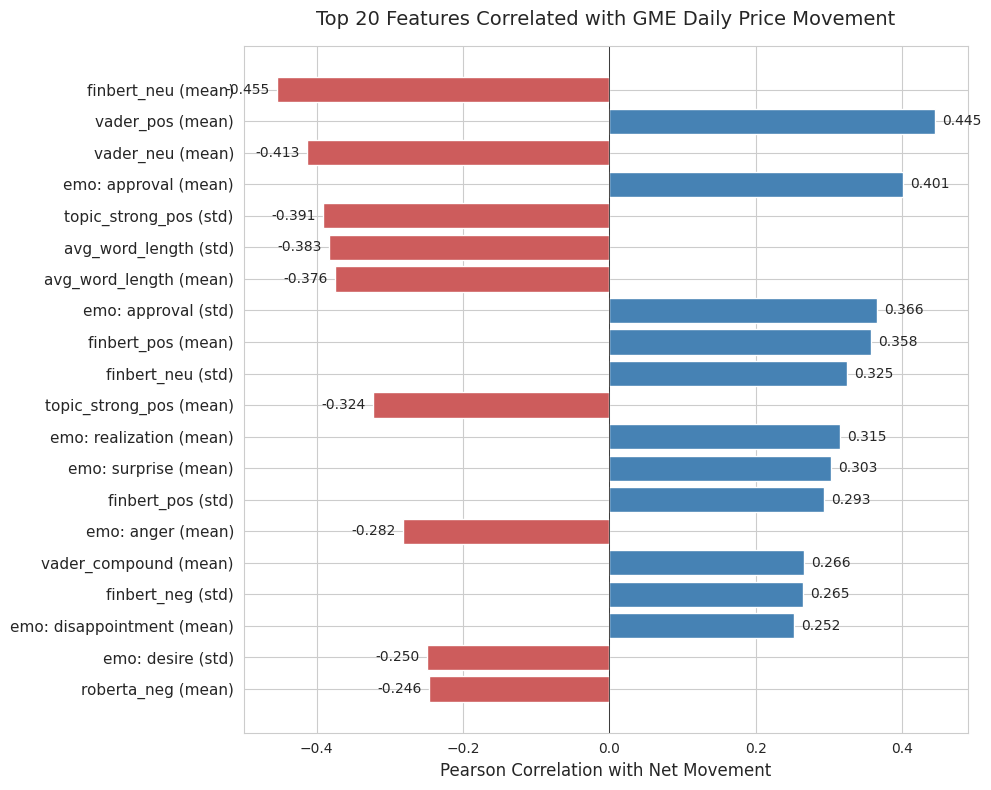

In [11]:
exclude_cols = ["Date", "Direction", "Net_Movement", "post_count"]
feature_cols = [c for c in df_daily.columns if c not in exclude_cols and df_daily[c].dtype in ["float64", "int64"]]

correlations = df_daily[feature_cols].corrwith(df_daily["Net_Movement"]).sort_values(key=abs, ascending=False)
top_20 = correlations.head(20)

labels = top_20.index.str.replace("_mean", " (mean)").str.replace("_std", " (std)").str.replace("emo_", "emo: ")
colors = ["steelblue" if v > 0 else "indianred" for v in top_20.values]

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(range(len(top_20)), top_20.values, color=colors, edgecolor="white")
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(labels, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel("Pearson Correlation with Net Movement", fontsize=12)
ax.set_title("Top 20 Features Correlated with GME Daily Price Movement", fontsize=14, pad=15)
ax.axvline(x=0, color="black", linewidth=0.5)

for i, (val, bar) in enumerate(zip(top_20.values, bars)):
    offset = 0.01 if val > 0 else -0.01
    ha = "left" if val > 0 else "right"
    ax.text(val + offset, i, f"{val:.3f}", va="center", ha=ha, fontsize=10)

fig.tight_layout()
plt.show()

## Section 7: Weighted vs. Unweighted Sentiment

This paired bar chart compares the Pearson correlation with net price movement for each sentiment feature under two aggregation strategies: unweighted daily means (blue) and upvote-weighted daily means (orange). This tests whether weighting by engagement produces a stronger predictive signal.

**Key findings:** Weighting by upvotes consistently and substantially weakens the correlation with price movement. In several cases — most notably FinBERT neutral (-0.455 unweighted vs. ~+0.2 weighted) and VADER positive (0.445 unweighted vs. ~0.0 weighted) — the weighting not only reduces magnitude but reverses the sign entirely. This occurs because the most upvoted posts on r/wallstreetbets tend to be memes and rallying cries — content that is popular but emotionally performative rather than reflective of market conditions. By weighting toward these posts, the signal from more analytical posts is drowned out. This is a valuable negative finding: engagement-weighted sentiment is demonstrably worse for price prediction, indicating that community curation through upvotes does not align with price-predictive information.

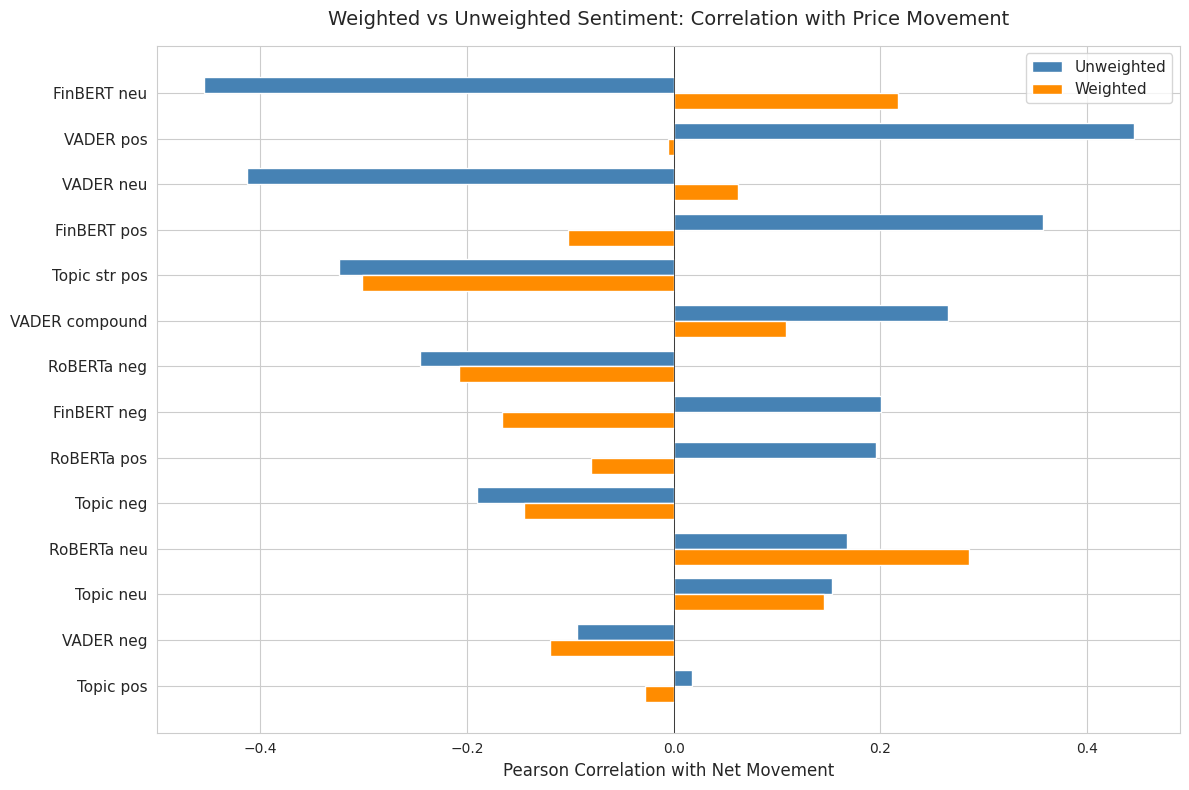

In [12]:
feature_pairs = [
    ("vader_pos_mean", "vader_pos_wmean", "VADER pos"),
    ("vader_neu_mean", "vader_neu_wmean", "VADER neu"),
    ("vader_neg_mean", "vader_neg_wmean", "VADER neg"),
    ("vader_compound_mean", "vader_compound_wmean", "VADER compound"),
    ("finbert_pos_mean", "finbert_pos_wmean", "FinBERT pos"),
    ("finbert_neu_mean", "finbert_neu_wmean", "FinBERT neu"),
    ("finbert_neg_mean", "finbert_neg_wmean", "FinBERT neg"),
    ("roberta_pos_mean", "roberta_pos_wmean", "RoBERTa pos"),
    ("roberta_neu_mean", "roberta_neu_wmean", "RoBERTa neu"),
    ("roberta_neg_mean", "roberta_neg_wmean", "RoBERTa neg"),
    ("topic_pos_mean", "topic_pos_wmean", "Topic pos"),
    ("topic_neu_mean", "topic_neu_wmean", "Topic neu"),
    ("topic_neg_mean", "topic_neg_wmean", "Topic neg"),
    ("topic_strong_pos_mean", "topic_strong_pos_wmean", "Topic str pos"),
]

unweighted_corrs = []
weighted_corrs = []
labels = []

for uw_col, w_col, label in feature_pairs:
    unweighted_corrs.append(df_daily[uw_col].corr(df_daily["Net_Movement"]))
    weighted_corrs.append(df_daily_weighted[w_col].corr(df_daily_weighted["Net_Movement"]))
    labels.append(label)

comp_df = pd.DataFrame({"Unweighted": unweighted_corrs, "Weighted": weighted_corrs, "Label": labels})
comp_df["abs_uw"] = comp_df["Unweighted"].abs()
comp_df = comp_df.sort_values("abs_uw", ascending=True).drop(columns="abs_uw")

fig, ax = plt.subplots(figsize=(12, 8))

y = np.arange(len(comp_df))
bar_height = 0.35

ax.barh(y + bar_height / 2, comp_df["Unweighted"], bar_height, label="Unweighted", color="steelblue", edgecolor="white")
ax.barh(y - bar_height / 2, comp_df["Weighted"], bar_height, label="Weighted", color="darkorange", edgecolor="white")

ax.set_yticks(y)
ax.set_yticklabels(comp_df["Label"], fontsize=11)
ax.set_xlabel("Pearson Correlation with Net Movement", fontsize=12)
ax.set_title("Weighted vs Unweighted Sentiment: Correlation with Price Movement", fontsize=14, pad=15)
ax.axvline(x=0, color="black", linewidth=0.5)
ax.legend(fontsize=11)

fig.tight_layout()
plt.show()